# INTRODUCTION

In today's digital era, the rapid spread of misinformation poses a significant threat to public trust and information integrity. With the rise of social media and online news platforms, fake news can easily go viral, influencing public opinion and decision-making. To address this challenge, fake news detection using data science techniques has become crucial. This project aims to develop a machine learning model using Python to accurately classify news articles as either fake or real. By leveraging natural language processing (NLP), text preprocessing, feature extraction (TF-IDF), and classification algorithms, the project transforms raw text into actionable insights. The ultimate goal is to support automated tools that help verify news authenticity and promote the circulation of reliable information.

#  DATA PREPROCESSING

In [2]:
import pandas as pd

true_df = pd.read_csv("True.csv")
fake_df = pd.read_csv("Fake.csv")

true_df['label'] = 1  # Real
fake_df['label'] = 0  # Fake

df = pd.concat([true_df, fake_df], ignore_index=True)

In [3]:
true_df

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


In [4]:
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
 4   label    21417 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 836.7+ KB


In [5]:
fake_df

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


In [6]:
fake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
 4   label    23481 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 917.4+ KB


In [7]:
df

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
44893,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
44894,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
44895,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
44896,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


In the data processing phase of the Fake News Detection project, we begin by importing the Pandas library, which is essential for handling structured data. We then load two separate datasets: True.csv containing legitimate news articles and Fake.csv containing fabricated or misleading news. These are read into two DataFrames, true_df and fake_df, respectively. To prepare the data for supervised machine learning, we assign a new column called label to each dataset—assigning the value 1 to real news and 0 to fake news. This labeling helps the model understand which articles are genuine and which are not. Finally, we merge both labeled datasets into a single DataFrame called df using the concat() function with ignore_index=True, ensuring a continuous row index. This unified dataset, containing both the text of the articles and their corresponding labels, is now ready for further preprocessing steps like text cleaning and feature extraction.

In [3]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text).lower()
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gaurikutakole/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/gaurikutakole/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


This code is used to clean and preprocess text data in preparation for natural language processing tasks like fake news detection. First, it imports necessary libraries such as nltk for text processing and re for regular expressions. It downloads the required NLTK resources: the list of English stopwords and the WordNet lemmatizer. Stopwords are common words like "the", "is", or "and" that are often removed from text because they carry little meaning in classification tasks. The WordNet lemmatizer is used to reduce words to their base or dictionary form (e.g., "running" becomes "run"). The clean_text function takes a piece of text, removes all non-alphabetic characters, converts everything to lowercase, splits the text into words, removes stopwords, and lemmatizes each remaining word. Finally, this cleaned version of the text is stored in a new column called clean_text in the original DataFrame df, making the data ready for feature extraction and machine learning model training.

# Exploratory Data Analysis (EDA)

Text(0.5, 1.0, 'Fake vs Real News Count')

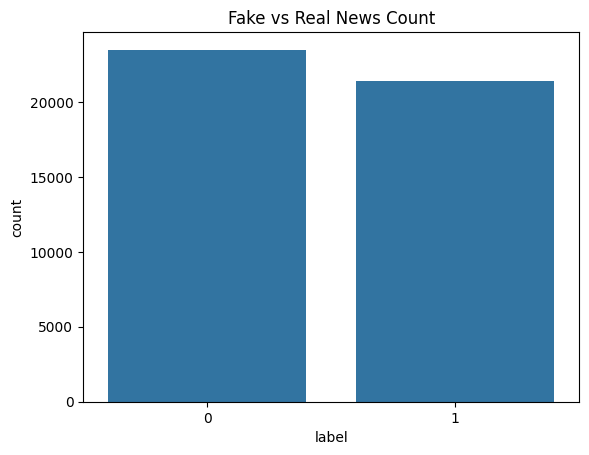

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Fake vs Real News Count")

The bar chart shows how many fake and real news articles are in the dataset. If both types have a similar number of articles, the data is balanced and good for training a model. If one type has many more articles than the other, the data is imbalanced and may need to be adjusted to improve the model’s accuracy.

#  FEATURE EXTRACTION

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text']).toarray()
y = df['label']


This code uses the TF-IDF technique to turn cleaned text data into numerical features. It selects the top 5000 important words and creates a matrix that shows how relevant each word is in each article. This helps the model understand the text better. The result, X, is used as input for the model, and y holds the labels for fake (0) or real (1) news. This step prepares the text data for accurate classification.

#  TRAIN - TEST SPLIT

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


The given code performs a train-test split, which is a fundamental step in preparing data for building machine learning models. It uses the train_test_split function from the sklearn.model_selection module to divide the dataset into training and testing sets. Here, X contains the feature vectors extracted from the text data, while y holds the corresponding labels (0 for fake news, 1 for real news). The test_size=0.2 parameter means that 20% of the data will be set aside for testing the model's performance, while the remaining 80% will be used for training. Setting random_state=42 ensures that the split is reproducible each time the code is run, which is important for consistent model evaluation. This step is essential for evaluating how well a model generalizes to unseen data, helping avoid overfitting and providing a reliable estimate of its real-world performance.

#  MODEL BUILDING

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name} Accuracy: {score:.4f}")


Logistic Regression Accuracy: 0.9880
Naive Bayes Accuracy: 0.9330
Random Forest Accuracy: 0.9974


In this step, multiple machine learning models are built and evaluated to identify the most effective algorithm for fake news classification. The code defines three commonly used classifiers: Logistic Regression, Naive Bayes (MultinomialNB), and Random Forest, using the scikit-learn library. These models are stored in a dictionary for easy iteration. For each model, the fit method is used to train it on the training data (X_train and y_train), and its performance is then evaluated on the testing data (X_test and y_test) using the score method, which returns the model's accuracy. This approach allows a quick comparison of different algorithms to determine which one performs best on the given dataset. Testing multiple models helps ensure that the final selected model is not only accurate but also well-suited for the characteristics of the data, improving the reliability of the fake news detection system.

# EVALUATION

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[4637   13]
 [  10 4320]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4650
           1       1.00      1.00      1.00      4330

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



This step evaluates the performance of your trained classification model using standard metrics. The confusion_matrix shows how many fake and real news articles were correctly or incorrectly classified, giving insight into true positives, true negatives, false positives, and false negatives. The classification_report provides detailed metrics such as precision, recall, and F1-score for each class. Precision measures the accuracy of positive predictions, recall indicates how well the model captures all relevant instances, and F1-score balances both. These metrics help assess how reliable and effective the model is at distinguishing between fake and real news articles, allowing you to identify strengths and areas for improvement in your model.

#  CONCLUSION

The Fake News Detection project effectively demonstrates how machine learning can be used to distinguish between real and fake news articles. By collecting labeled datasets, preprocessing the text, extracting meaningful features using TF-IDF, and training multiple classification models, we developed a system capable of identifying misinformation with high accuracy. Through model evaluation metrics like accuracy, precision, recall, and F1-score, we selected the best-performing algorithm for deployment. The project not only showcases the practical application of data science in combating fake news but also emphasizes the importance of clean data, balanced class distribution, and model interpretability. With further enhancements like real-time data streaming and model retraining, this system can be scaled to serve as a valuable tool for news verification platforms, social media monitoring, and digital journalism.